In [4]:
from lappy import *
import numpy as np
import matplotlib.pyplot as plt

In [5]:
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


# GWW domains

How small can we get the tension for the first eigenvalue?

In [6]:
%%memit
gww = geometry.GWW1()
def gww_eig1_tension(n_fb_basis, n_fs_basis, d, bdry_nodes, int_nodes, rtol=1e-14, ltol=5e-16):
    """Solve for the first eigenvalue of the GWW-1 domain using n_fb_basis Fourier-Bessel
    basis functions (count proportional to interior angle of singular corners) and n_fs_basis 
    fundamental solution sources (proportional to edge length) spaced distance d from the boundary"""

    # set up Fourier-Bessel Basis
    if n_fb_basis > 0:
        int_angles = gww.int_angles
        reg_corner_idx = ((np.pi/int_angles % 1) < 1e-16)
        singular_angles = int_angles[~reg_corner_idx]
        orders = np.zeros(int_angles.shape, dtype=int)
        orders[~reg_corner_idx] = np.ceil(n_fb_basis*singular_angles/singular_angles.sum()).astype(int)
        fb_basis = FourierBesselBasis.from_domain(gww, orders)
        while orders.sum() > n_fb_basis:
            orders[orders.argmax()] -= 1
        while orders.sum() < n_fb_basis:
            orders[orders.argmin()] += 1

    # set up fundamental solution basis
    seg_lens = np.array([seg.len for seg in gww.bdry.segments])
    if n_fs_basis > 0:
        n_per_seg = np.ceil(n_fs_basis*seg_lens/seg_lens.sum()).astype(int)
        fs_basis = FundamentalBasis.from_domain(gww, n_per_seg, d)
        while n_per_seg.sum() > n_fs_basis:
            n_per_seg[n_per_seg.argmax()] -= 1
        while n_per_seg.sum() < n_fs_basis:
            n_per_seg[n_per_seg.argmin()] += 1

    # combine
    if n_fb_basis > 0 and n_fs_basis > 0:
        basis = fb_basis + fs_basis
    elif n_fb_basis > 0:
        basis = fb_basis
    elif n_fs_basis > 0:
        basis = fs_basis
    else:
        raise ValueError("need nonzero number of basis functions")

    # normalize basis
    basis = basis.to_normalized((bdry_nodes,int_nodes))
    
    # setup solver
    solver = MPSEigensolver(basis, bdry_nodes, int_nodes, rtol=rtol, ltol=ltol)

    # use golden search for first eigenvalue
    eig1 = opt.golden_search(solver.sigma, 2.53794, 2.53795, tol=2.54*ltol)[0]

    return eig1, solver.sigma(eig1), solver

peak memory: 173.17 MiB, increment: 0.02 MiB


## Fourier-Bessel basis count

In [7]:
%%memit
fb_min = 40
fb_max = 600
skip = 40
N_fb_basis = np.arange(fb_min, fb_max+1)[::skip]
print(N_fb_basis)

# build collocation points
n_bdry = 2*fb_max
seg_lens = np.array([seg.len for seg in gww.bdry.segments])
n_per_seg = np.ceil(n_bdry*seg_lens/seg_lens.sum()).astype(int)
bdry_nodes = gww.bdry_pts(n_per_seg, weights=True)
int_nodes = gww.int_pts(method='mesh', mesh_size=.5, weights=True)

[ 40  80 120 160 200 240 280 320 360 400 440 480 520 560 600]
peak memory: 178.31 MiB, increment: 5.14 MiB


In [8]:
%%memit
eigs, tensions = [], []
for n_fb_basis in N_fb_basis:
    print(n_fb_basis)
    eig1, sigma = gww_eig1_tension(n_fb_basis, 0, 0, bdry_nodes, int_nodes, rtol=1e-14)[:2]
    eigs.append(eig1)
    tensions.append(sigma)
fb_data = {}
fb_data['eigs'] = np.array(eigs)
fb_data['tensions'] = np.array(tensions)

40
80
120
160
200
240
280
320
360
400
440
480
520
560
600
peak memory: 453.39 MiB, increment: 275.08 MiB


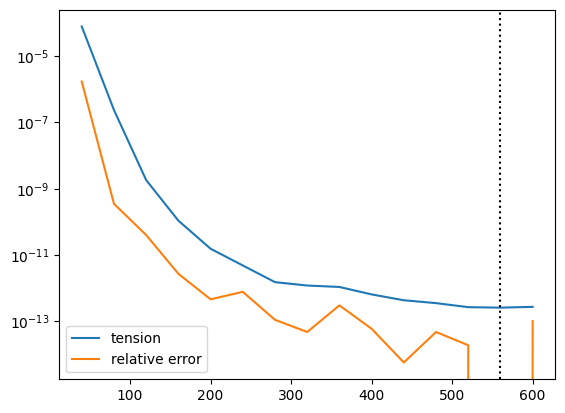

In [9]:
best_idx = fb_data['tensions'].argmin()
relerr = np.abs(fb_data['eigs']-fb_data['eigs'][best_idx])/fb_data['eigs'][best_idx]
plt.semilogy(N_fb_basis, fb_data['tensions'], label='tension')
plt.semilogy(N_fb_basis, relerr, label='relative error')
plt.axvline(N_fb_basis[best_idx], linestyle=':', c='k')
plt.legend()
plt.title("")
plt.show()

In [49]:
fb_data['tensions'].min()

np.float64(2.5291770814425207e-13)

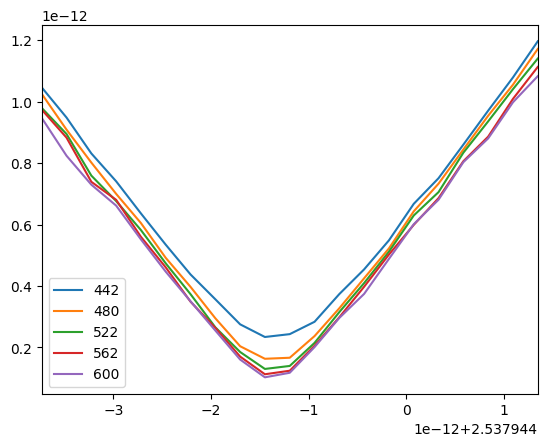

In [12]:
fig, ax = plt.subplots()
for solver in solvers[-5:]:
    solver.plot_tensions(fb_data['eigs'][-1]*(1-1e-12), fb_data['eigs'][-1]*(1+1e-12), 20, mps_kwargs={'rtol':1e-15},
                         ax=ax, label=f"{len(solver.basis)}", n_workers=10)
# ax.set_yscale('log')
plt.legend()
plt.show()

## Fundamental solution basis source distance

In [10]:
n_fs_basis = 100
D = np.logspace(-2,2,21)

eigs, tensions = [], []
solvers = []
for d in D:
    print(d)
    eig1, sigma, solver = gww_eig1_tension(0, n_fs_basis, d, bdry_nodes, int_nodes)
    eigs.append(eig1)
    tensions.append(sigma)
fs_d_data = {}
fs_d_data['eigs'] = np.array(eigs)
fs_d_data['tensions'] = np.array(tensions)

0.01
0.015848931924611134
0.025118864315095794
0.039810717055349734
0.06309573444801933
0.1
0.15848931924611143
0.25118864315095807
0.3981071705534973
0.6309573444801934
1.0
1.584893192461114
2.5118864315095824
3.981071705534973
6.309573444801936
10.0
15.848931924611142
25.11886431509582
39.810717055349734
63.095734448019364
100.0


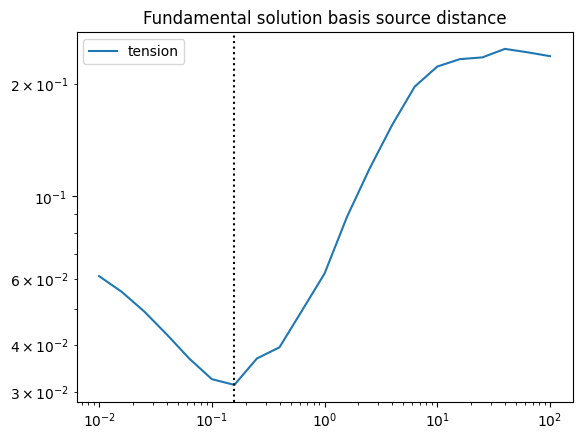

In [11]:
best_idx = fs_d_data['tensions'].argmin()
relerr = np.abs(fs_d_data['eigs']-fs_d_data['eigs'][best_idx])/fs_d_data['eigs'][best_idx]
plt.loglog(D, fs_d_data['tensions'], label='tension')
# plt.loglog(D, relerr, label='relative error')
plt.axvline(D[best_idx], linestyle=':', c='k')
plt.legend()
plt.title("Fundamental solution basis source distance")
plt.show()

In [12]:
D[best_idx]

np.float64(0.15848931924611143)

## Fundamental solution basis count

In [13]:
fs_min = 40
fs_max = 600
skip = 40
N_fs_basis = np.arange(fs_min, fs_max+1)[::skip]
print(N_fs_basis)

# build collocation points
n_bdry = 2*fs_max
seg_lens = np.array([seg.len for seg in gww.bdry.segments])
n_per_seg = np.ceil(n_bdry*seg_lens/seg_lens.sum()).astype(int)
bdry_nodes = gww.bdry_pts(n_per_seg, weights=True)
int_nodes = gww.int_pts(method='mesh', mesh_size=.5, weights=True)

[ 40  80 120 160 200 240 280 320 360 400 440 480 520 560 600]


In [14]:
eigs, tensions = [], []
solvers = []
for n_fs_basis in N_fs_basis:
    print(n_fs_basis)
    eig1, sigma, solver = gww_eig1_tension(0, n_fs_basis, .15, bdry_nodes, int_nodes)
    eigs.append(eig1)
    tensions.append(sigma)
fs_data = {}
fs_data['eigs'] = np.array(eigs)
fs_data['tensions'] = np.array(tensions)

40
80
120
160
200
240
280
320
360
400
440
480
520
560
600


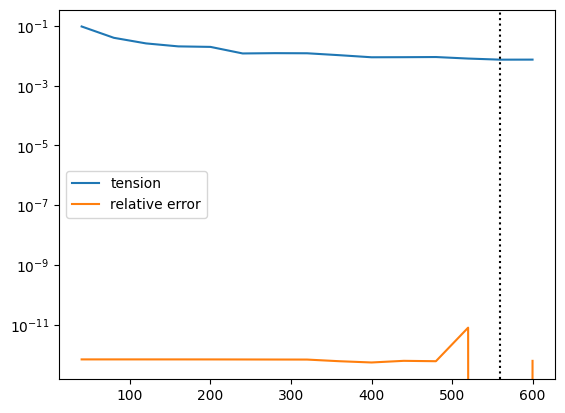

In [15]:
best_idx = fs_data['tensions'].argmin()
relerr = np.abs(fs_data['eigs']-fs_data['eigs'][best_idx])/fs_data['eigs'][best_idx]
plt.semilogy(N_fs_basis, fs_data['tensions'], label='tension')
plt.semilogy(N_fs_basis, relerr, label='relative error')
plt.axvline(N_fs_basis[best_idx], linestyle=':', c='k')
plt.legend()
plt.title("")
plt.show()

## Fourier-Bessel with fundamental solutions

In [30]:
fb_min = 40
fb_max = 600
skip = 40
N_fb_basis = np.arange(fb_min, fb_max+1)[::skip]
print(N_fb_basis)

fs_min = 40
fs_max = 600
skip = 40
N_fs_basis = np.arange(fs_min, fs_max+1)[::skip]
print(N_fs_basis)

# build collocation points
n_bdry = 2*(fb_max + fs_max)
seg_lens = np.array([seg.len for seg in gww.bdry.segments])
n_per_seg = np.ceil(n_bdry*seg_lens/seg_lens.sum()).astype(int)
bdry_nodes = gww.bdry_pts(n_per_seg, weights=True)
int_nodes = gww.int_pts(method='mesh', mesh_size=.5, weights=True)

[ 40  80 120 160 200 240 280 320 360 400 440 480 520 560 600]
[ 40  80 120 160 200 240 280 320 360 400 440 480 520 560 600]


In [31]:
eigs, tensions = [], []
for n_fb_basis, n_fs_basis in zip(N_fb_basis, N_fs_basis):
    print(n_fs_basis)
    eig1, sigma, solver = gww_eig1_tension(n_fb_basis, n_fs_basis, .15, bdry_nodes, int_nodes)
    eigs.append(eig1)
    tensions.append(sigma)
fb_fs_data = {}
fb_fs_data['eigs'] = np.array(eigs)
fb_fs_data['tensions'] = np.array(tensions)

40
80
120
160
200
240
280
320
360
400
440
480
520
560
600


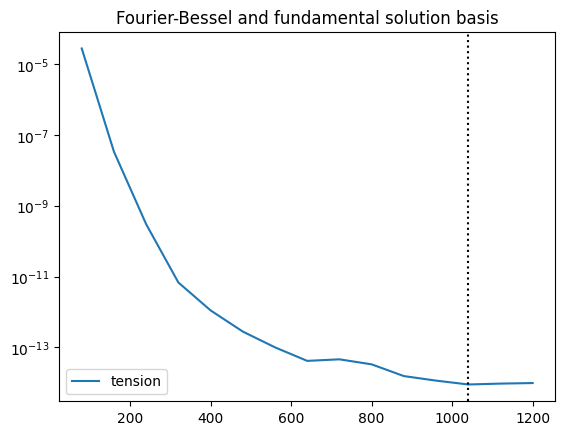

In [47]:
best_idx = fb_fs_data['tensions'].argmin()
relerr = np.abs(fb_fs_data['eigs']-fb_fs_data['eigs'][best_idx])/fb_fs_data['eigs'][best_idx]
plt.semilogy((N_fb_basis+N_fs_basis), fb_fs_data['tensions'], label='tension')
# plt.semilogy((N_fb_basis+N_fs_basis), relerr, label='relative error')
plt.axvline((N_fb_basis+N_fs_basis)[best_idx], linestyle=':', c='k')
plt.legend()
plt.title("Fourier-Bessel and fundamental solution basis")
plt.show()

In [48]:
fb_fs_data['tensions']

array([2.81200849e-05, 3.38954580e-08, 3.02160923e-10, 6.79708974e-12,
       1.10556052e-12, 2.78784581e-13, 9.96878402e-14, 4.13555067e-14,
       4.57287263e-14, 3.30109714e-14, 1.53723070e-14, 1.14353793e-14,
       8.89623842e-15, 9.41881249e-15, 9.76033233e-15])

# Chevron Domain

In [57]:
chev = geometry.chevron()
def chev_eig1_tension(n_fb_basis, n_fs_basis, d, bdry_nodes, int_nodes, rtol=1e-14, ltol=5e-16):
    """Solve for the first eigenvalue of the Chevron domain using n_fb_basis Fourier-Bessel
    basis functions (count proportional to interior angle of singular corners) and n_fs_basis 
    fundamental solution sources (proportional to edge length) spaced distance d from the boundary"""

    # set up Fourier-Bessel Basis
    if n_fb_basis > 0:
        int_angles = chev.int_angles
        reg_corner_idx = ((np.pi/int_angles % 1) < 1e-16)
        singular_angles = int_angles[~reg_corner_idx]
        orders = np.zeros(int_angles.shape, dtype=int)
        orders[~reg_corner_idx] = np.ceil(n_fb_basis*singular_angles/singular_angles.sum()).astype(int)
        fb_basis = FourierBesselBasis.from_domain(chev, orders)
        while orders.sum() > n_fb_basis:
            orders[orders.argmax()] -= 1
        while orders.sum() < n_fb_basis:
            orders[orders.argmin()] += 1

    # set up fundamental solution basis
    seg_lens = np.array([seg.len for seg in chev.bdry.segments])
    if n_fs_basis > 0:
        n_per_seg = np.ceil(n_fs_basis*seg_lens/seg_lens.sum()).astype(int)
        fs_basis = FundamentalBasis.from_domain(chev, n_per_seg, d)
        while n_per_seg.sum() > n_fs_basis:
            n_per_seg[n_per_seg.argmax()] -= 1
        while n_per_seg.sum() < n_fs_basis:
            n_per_seg[n_per_seg.argmin()] += 1

    # combine
    if n_fb_basis > 0 and n_fs_basis > 0:
        basis = fb_basis + fs_basis
    elif n_fb_basis > 0:
        basis = fb_basis
    elif n_fs_basis > 0:
        basis = fs_basis
    else:
        raise ValueError("need nonzero number of basis functions")

    # normalize basis
    basis = basis.to_normalized((bdry_nodes,int_nodes))
    
    # setup solver
    solver = MPSEigensolver(basis, bdry_nodes, int_nodes, rtol=rtol, ltol=ltol)

    # use golden search for first eigenvalue
    eig1 = opt.golden_search(solver.sigma, 39, 40, tol=2.54*ltol)[0]

    return eig1, solver.sigma(eig1), solver

In [58]:
fb_min = 40
fb_max = 600
skip = 40
N_fb_basis = np.arange(fb_min, fb_max+1)[::skip]
print(N_fb_basis)

# build collocation points
n_bdry = 2*fb_max
seg_lens = np.array([seg.len for seg in chev.bdry.segments])
n_per_seg = np.ceil(n_bdry*seg_lens/seg_lens.sum()).astype(int)
bdry_nodes = chev.bdry_pts(n_per_seg, weights=True)
int_nodes = chev.int_pts(method='mesh', mesh_size=.5, weights=True)

[ 40  80 120 160 200 240 280 320 360 400 440 480 520 560 600]


In [60]:
eigs, tensions = [], []
for n_fb_basis in N_fb_basis:
    print(n_fb_basis)
    eig1, sigma, solver = chev_eig1_tension(n_fb_basis, 0, 0, bdry_nodes, int_nodes, rtol=1e-14)
    eigs.append(eig1)
    tensions.append(sigma)
chev_fb_data = {}
chev_fb_data['eigs'] = np.array(eigs)
chev_fb_data['tensions'] = np.array(tensions)

40
80
120
160
200
240
280
320
360
400
440
480
520
560
600


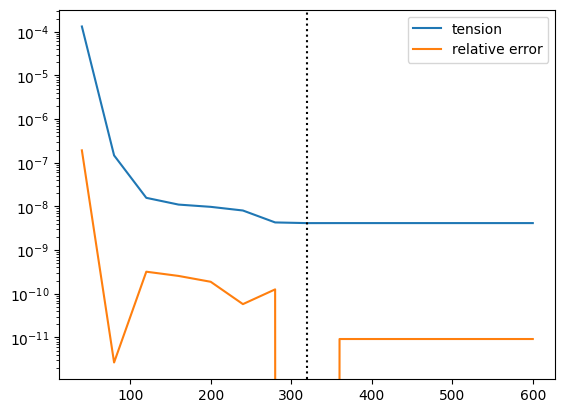

In [61]:
best_idx = chev_fb_data['tensions'].argmin()
relerr = np.abs(chev_fb_data['eigs']-chev_fb_data['eigs'][best_idx])/chev_fb_data['eigs'][best_idx]
plt.semilogy(N_fb_basis, chev_fb_data['tensions'], label='tension')
plt.semilogy(N_fb_basis, relerr, label='relative error')
plt.axvline(N_fb_basis[best_idx], linestyle=':', c='k')
plt.legend()
plt.title("")
plt.show()

## FS source distance

In [63]:
n_fs_basis = 100
D = np.logspace(-2,2,21)

eigs, tensions = [], []
solvers = []
for d in D:
    print(d)
    eig1, sigma, solver = chev_eig1_tension(0, n_fs_basis, d, bdry_nodes, int_nodes)
    eigs.append(eig1)
    tensions.append(sigma)
chev_fs_d_data = {}
chev_fs_d_data['eigs'] = np.array(eigs)
chev_fs_d_data['tensions'] = np.array(tensions)

0.01
0.015848931924611134
0.025118864315095794
0.039810717055349734
0.06309573444801933
0.1
0.15848931924611143
0.25118864315095807
0.3981071705534973
0.6309573444801934
1.0
1.584893192461114
2.5118864315095824
3.981071705534973
6.309573444801936
10.0
15.848931924611142
25.11886431509582
39.810717055349734
63.095734448019364
100.0


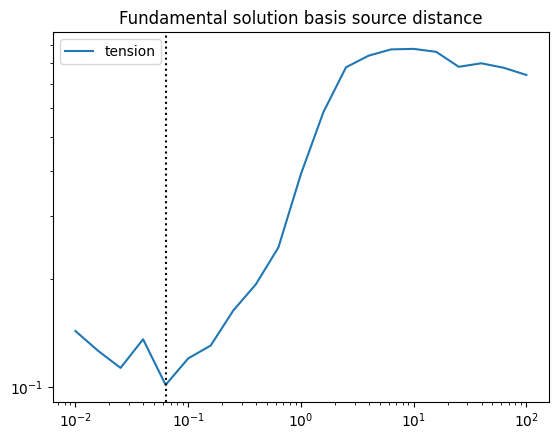

In [64]:
best_idx = chev_fs_d_data['tensions'].argmin()
relerr = np.abs(chev_fs_d_data['eigs']-chev_fs_d_data['eigs'][best_idx])/chev_fs_d_data['eigs'][best_idx]
plt.loglog(D, chev_fs_d_data['tensions'], label='tension')
# plt.loglog(D, relerr, label='relative error')
plt.axvline(D[best_idx], linestyle=':', c='k')
plt.legend()
plt.title("Fundamental solution basis source distance")
plt.show()

In [66]:
D[chev_fs_d_data['tensions'].argmin()]

np.float64(0.06309573444801933)

In [68]:
fb_min = 40
fb_max = 600
skip = 40
N_fb_basis = np.arange(fb_min, fb_max+1)[::skip]
print(N_fb_basis)

fs_min = 40
fs_max = 600
skip = 40
N_fs_basis = np.arange(fs_min, fs_max+1)[::skip]
print(N_fs_basis)

# build collocation points
n_bdry = 2*(fb_max + fs_max)
seg_lens = np.array([seg.len for seg in chev.bdry.segments])
n_per_seg = np.ceil(n_bdry*seg_lens/seg_lens.sum()).astype(int)
bdry_nodes = chev.bdry_pts(n_per_seg, weights=True)
int_nodes = chev.int_pts(method='mesh', mesh_size=.5, weights=True)

[ 40  80 120 160 200 240 280 320 360 400 440 480 520 560 600]
[ 40  80 120 160 200 240 280 320 360 400 440 480 520 560 600]


In [69]:
eigs, tensions = [], []
for n_fb_basis, n_fs_basis in zip(N_fb_basis, N_fs_basis):
    print(n_fs_basis)
    eig1, sigma, solver = chev_eig1_tension(n_fb_basis, n_fs_basis, .05, bdry_nodes, int_nodes)
    eigs.append(eig1)
    tensions.append(sigma)
chev_fb_fs_data = {}
chev_fb_fs_data['eigs'] = np.array(eigs)
chev_fb_fs_data['tensions'] = np.array(tensions)

40
80
120
160
200
240
280
320
360
400
440
480
520
560
600


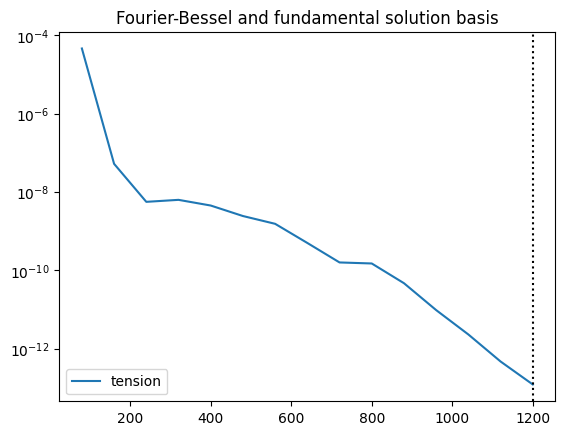

In [70]:
best_idx = chev_fb_fs_data['tensions'].argmin()
relerr = np.abs(chev_fb_fs_data['eigs']-chev_fb_fs_data['eigs'][best_idx])/chev_fb_fs_data['eigs'][best_idx]
plt.semilogy((N_fb_basis+N_fs_basis), chev_fb_fs_data['tensions'], label='tension')
# plt.semilogy((N_fb_basis+N_fs_basis), relerr, label='relative error')
plt.axvline((N_fb_basis+N_fs_basis)[best_idx], linestyle=':', c='k')
plt.legend()
plt.title("Fourier-Bessel and fundamental solution basis")
plt.show()

In [71]:
eig1, sigma, solver = chev_eig1_tension(300, 900, .05, bdry_nodes, int_nodes)

In [72]:
sigma

np.float64(5.886214635660562e-15)

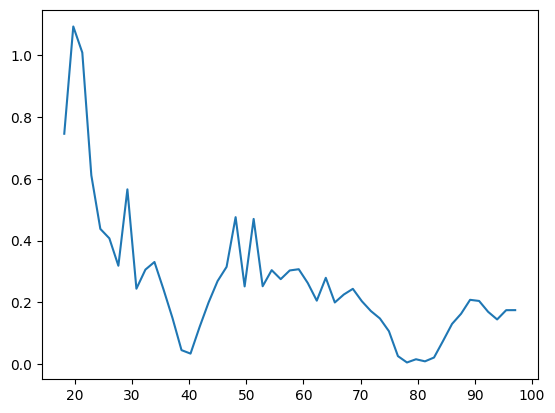

In [73]:
solver.plot_tensions(bounds.faber_krahn(chev), asymp.weyl_est(2, chev), 50)
plt.show()

In [74]:
eig1

39.665875367628416

In [76]:
# chevron
chev_data = np.load('chevron_1.0_2.0_e10_fb200_fs400.npz')
chev_data['eigs'], chev_data['relerr_est']

(array([ 39.66587537,  77.66316267,  81.88608149, 111.42970386,
        120.59489371, 152.06601347, 161.16007983, 179.80395818,
        204.70479739, 205.98199724]),
 array([5.43926845e-14, 2.90372468e-14, 6.75743100e-14, 8.57303738e-14,
        1.05888847e-13, 5.34028553e-13, 1.16561381e-12, 2.46469750e-13,
        5.25202612e-14, 5.05677630e-13]))

In [77]:
np.set_printoptions(precision=16)
print(repr(chev_data['eigs']))

array([ 39.66587536762846,  77.66316267381548,  81.88608149069968,
       111.42970385691103, 120.59489370950362, 152.06601346806502,
       161.16007983417921, 179.80395817996902, 204.7047973867004 ,
       205.98199724200455])


In [78]:
# iso_tri
iso_tri_data = np.load('iso_tri_20.0_e10_fb200_fs300.npz')
iso_tri_data['eigs'], iso_tri_data['relerr_est']

(array([ 3.538204270133983,  4.552162970620473,  5.539932740921296,
         6.544007125902493,  7.578949068369423,  8.651562362007823,
         9.765571848342804, 10.923228519465912, 12.125988718163306,
        12.4252704009599  ]),
 array([4.7904282709428332e-14, 1.1306161624633960e-13,
        3.4970447680704494e-13, 4.4303364556818036e-13,
        5.5408288066407425e-13, 4.6323758479735969e-13,
        9.3119368941493915e-14, 7.1118342615592757e-14,
        3.0765366474456244e-14, 1.2802891847870467e-13]))

In [79]:
np.set_printoptions(precision=16)
print(repr(iso_tri_data['eigs']))

array([ 3.538204270133983,  4.552162970620473,  5.539932740921296,
        6.544007125902493,  7.578949068369423,  8.651562362007823,
        9.765571848342804, 10.923228519465912, 12.125988718163306,
       12.4252704009599  ])


In [81]:
(1 + 1e-12) - 1

1.000088900582341e-12

In [82]:
1 + 1e-12

1.000000000001

In [83]:
1

1